# **Imports**

In [1]:

from earthscape.constants import VERSION, ASSETS_DIR, MODEL_DIR, SG_MAPPING, SG_COLORS
from earthscape.models import create_unet_seg, create_deeplabv3p_seg, create_segformer_seg
from earthscape.loaders import ESDataset_Classification
from earthscape.evaluation import test_model_seg

import os
import glob
import yaml
import numpy as np
import pandas as pd
from scipy.stats import t
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
import seaborn as sns

from scipy import stats

from earthscape.analysis.data_processing import parse_input_label, parse_features, spatial_support

import matplotlib as mpl
mpl.rcParams["svg.fonttype"] = "none"

# **Setup**

In [2]:
#############################################
# Setup input and output directories & paths
#############################################

# directory of experiments
exp_dir = r'../experiments/baselines/segmentation'

# single modality experiments...
single_root = os.path.join(exp_dir, 'single')
single_dirs = glob.glob(f"{single_root}/*")

# multi-scale modality experiments...
ms_root = os.path.join(exp_dir, 'multiscale')
ms_dirs = glob.glob(f"{ms_root}/*")

# multimodal experiments modalities...
mm_root = os.path.join(exp_dir, 'multimodal')
mm_dirs = glob.glob(f"{mm_root}/*")

# output directory for visualizations...
assets_dir = os.path.join(exp_dir.replace(MODEL_DIR, ASSETS_DIR))
if not os.path.isdir(assets_dir):
    os.makedirs(assets_dir)


# **Model Performance**

## *Experiment Compilation*

In [ ]:
##################################################
# Compile Global Performance Metrics - Single
##################################################

# # output path for global summary
# output_path = os.path.join(assets_dir, 'single_global.csv')


##### compile global in- & cross-domain data...
# initialize df
df_single = pd.DataFrame(columns=['model', 'encoder', 'input'])

# collect global data from all experiments...
for idx, d in enumerate(single_dirs):
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0].split('-')[0]
    encoder_name = meta[0].split('-')[1]
    modalities = meta[1]

    # in-domain...
    id_global_path = os.path.join(d, 'id_overall.csv')
    id = pd.read_csv(id_global_path)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_overall.csv')
    cd = pd.read_csv(cd_global_path)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df_single.loc[idx, 'model'] = model_name
    df_single.loc[idx, 'encoder'] = encoder_name
    df_single.loc[idx, 'input'] = modalities
    df_single.loc[idx, id.columns] = id.values
    df_single.loc[idx, cd.columns] = cd.values


# # save & display...
# df.to_csv(output_path, index=False)
# df.sort_values('micro_iou (id)', ascending=False).head()

In [ ]:
##################################################
# Compile Global Performance Metrics - Multiscale
##################################################

# # output path for global summary
# output_path = os.path.join(assets_dir, 'multiscale_global.csv')


##### compile global in- & cross-domain data...
# initialize df
df_ms = pd.DataFrame(columns=['model', 'encoder', 'input'])

# collect global data from all experiments...
for idx, d in enumerate(ms_dirs):
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0].split('-')[0]
    encoder_name = meta[0].split('-')[1]
    modalities = meta[1]

    # in-domain...
    id_global_path = os.path.join(d, 'id_overall.csv')
    id = pd.read_csv(id_global_path)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_overall.csv')
    cd = pd.read_csv(cd_global_path)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df_ms.loc[idx, 'model'] = model_name
    df_ms.loc[idx, 'encoder'] = encoder_name
    df_ms.loc[idx, 'input'] = modalities
    df_ms.loc[idx, id.columns] = id.values
    df_ms.loc[idx, cd.columns] = cd.values


# # save & display...
# df.to_csv(output_path, index=False)
# df.sort_values('micro_iou (id)', ascending=False).head()

In [ ]:
##################################################
# Compile Global Performance Metrics - Multimodal
##################################################

# # output path for global summary
# output_path = os.path.join(assets_dir, 'multimodal_global.csv')


##### compile global in- & cross-domain data...
# initialize df
df_mm = pd.DataFrame(columns=['model', 'encoder', 'input'])

# collect global data from all experiments...
for idx, d in enumerate(mm_dirs):
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0].split('-')[0]
    encoder_name = meta[0].split('-')[1]
    modalities = meta[1]

    # in-domain...
    id_global_path = os.path.join(d, 'id_overall.csv')
    id = pd.read_csv(id_global_path)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_overall.csv')
    cd = pd.read_csv(cd_global_path)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df_mm.loc[idx, 'model'] = model_name
    df_mm.loc[idx, 'encoder'] = encoder_name
    df_mm.loc[idx, 'input'] = modalities
    df_mm.loc[idx, id.columns] = id.values
    df_mm.loc[idx, cd.columns] = cd.values


# # save & display...
# df.to_csv(output_path, index=False)
# df.sort_values('micro_iou (id)', ascending=False).head()

In [ ]:
##################################################
# Compile All Global Experiments
##################################################

# # paths to single, multi-scale, & multimodal compilations...
# single_path = os.path.join(assets_dir, "single_global.csv")
# ms_path = os.path.join(assets_dir, "multiscale_global.csv")
# mm_path = os.path.join(assets_dir, "multimodal_global.csv")

# output path
output_path = os.path.join(assets_dir, 'compiled_global.csv')


# ##### compile data...
# df_list = []
# df_list.append(pd.read_csv(single_path))
# df_list.append(pd.read_csv(ms_path))
# df_list.append(pd.read_csv(mm_path))

df = pd.concat([df_single, df_ms, df_mm])
df.reset_index(drop=True, inplace=True)

df.to_csv(output_path, index=False)
df.sort_values('micro_iou (id)', ascending=False).head()

,model,encoder,input,macro_iou (id),macro_dice (id),macro_precision (id),macro_recall (id),micro_iou (id),micro_dice (id),micro_precision (id),...,macro_iou (cd),macro_dice (cd),macro_precision (cd),macro_recall (cd),micro_iou (cd),micro_dice (cd),micro_precision (cd),micro_recall (cd),mean_hd (cd),mean_hd95 (cd)
179,unet,resnet18,ep-ms+prc-ms+s-ms,0.498217,0.559482,0.620749,0.569213,0.801956,0.890095,0.890095,...,0.421719,0.479869,0.526230,0.494885,0.759270,0.863165,0.863165,0.863165,95.092682,75.278611
165,deeplabv3p,resnet50,prc-ms+s-ms,0.512490,0.575337,0.635278,0.583955,0.799682,0.888693,0.888692,...,0.463329,0.523455,0.574666,0.538645,0.776328,0.874082,0.874082,0.874082,88.370076,71.160174
183,unet,resnet18,prc-ms+s-ms,0.495536,0.557914,0.615054,0.570558,0.798920,0.888222,0.888222,...,0.417799,0.476382,0.529127,0.495688,0.749643,0.856909,0.856910,0.856910,97.683011,77.606396
161,deeplabv3p,resnet50,ep-ms+prc-ms+s-ms,0.517403,0.579121,0.642594,0.589566,0.798666,0.888065,0.888065,...,0.450268,0.509555,0.569154,0.523452,0.761464,0.864581,0.864581,0.864581,91.516889,73.818294
163,deeplabv3p,resnet50,ep-ms+s-ms+sds-ms,0.500392,0.561720,0.618571,0.571191,0.798437,0.887923,0.887923,...,0.443377,0.502536,0.556308,0.517657,0.769382,0.869662,0.869662,0.869662,90.872558,73.812591


## *Visualizations*

### Modality Rankings

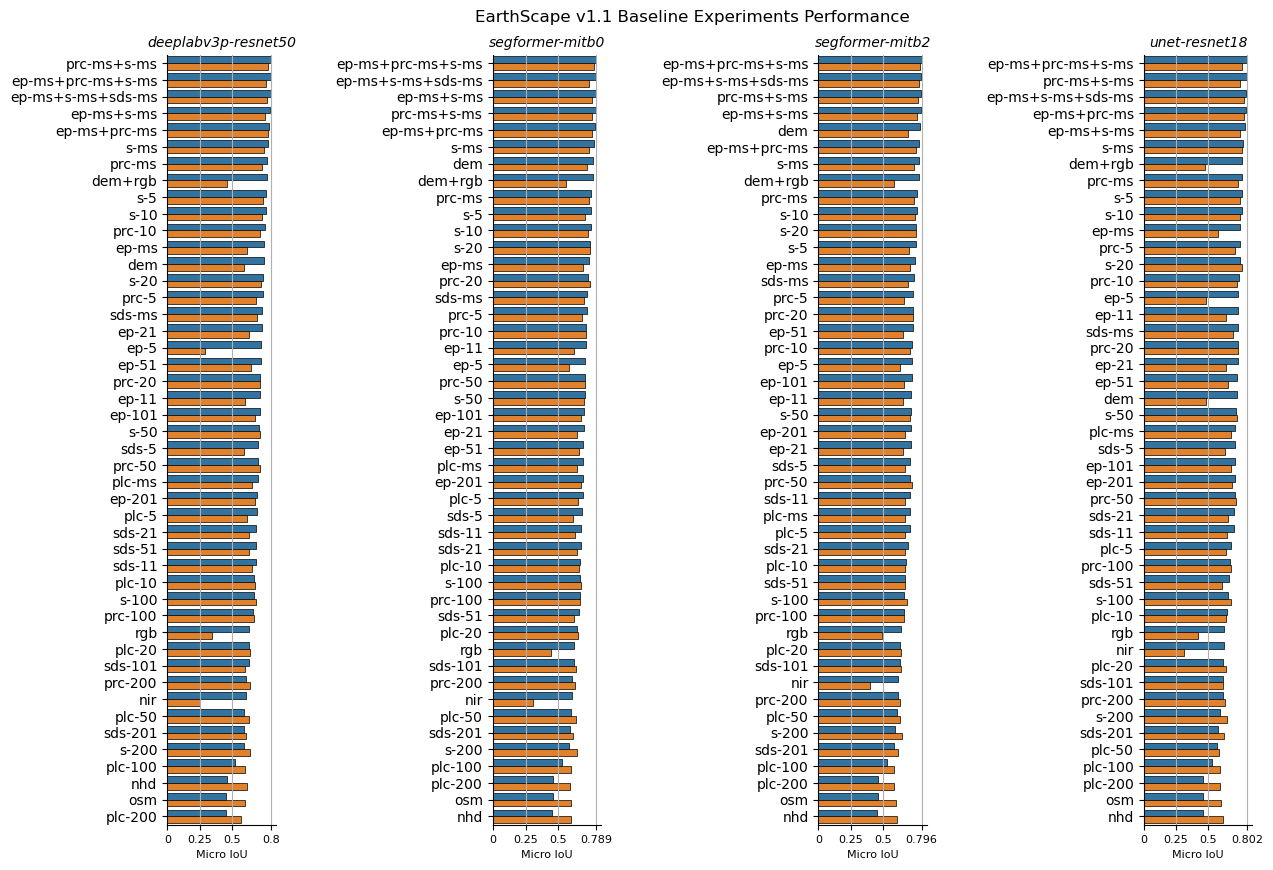

In [3]:
#############################################
# Modality Ranking Bar Charts - All Experiments
#############################################

# path to compiled data...
single_path = os.path.join(assets_dir, 'compiled_global.csv')
df_single = pd.read_csv(single_path)

# metric to plot...
metric = 'iou'
metric_label = 'Micro IoU'

# models to use...
models = ['unet-resnet18', 'deeplabv3p-resnet50', 'segformer-mitb0', 'segformer-mitb2']

# output path for figure
output_path = os.path.join(assets_dir, 'rankings_all_iou.png')


##### plot bar chart rankings...
fig, ax = plt.subplots(ncols=len(models), figsize=(3.5*len(models), 10))
plt.subplots_adjust(wspace=2)
ax = ax.ravel()

df_single['model-encoder'] = df_single['model'] + '-' + df_single['encoder']

idx = 0
for m in df_single['model-encoder'].unique():

    if m in models:

        df = df_single[df_single['model-encoder'] == m].copy()
        df.sort_values(f"micro_{metric} (id)", ascending=False, inplace=True)
        order = df['input'].to_list()
        max_val = df[f"micro_{metric} (id)"].max().item()
        df_plot = df.melt(id_vars=['input'], value_vars=[f"micro_{metric} (id)", f"micro_{metric} (cd)"], var_name='domain', value_name=metric)
        sns.barplot(ax=ax[idx], data=df_plot, x=metric, y='input', hue='domain', order=order, edgecolor='k', linewidth=0.5, legend=False)
        ax[idx].set_title(m, style='italic', fontsize=10)
        ax[idx].set_xticks([0, 0.25, 0.5, max_val])
        ax[idx].set_xticklabels(ax[idx].get_xticklabels(), fontsize=8)
        ax[idx].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.3f}".rstrip('0').rstrip('.')))
        idx += 1

for axes in ax:
    axes.set_xlabel(f"{metric_label}", fontsize=8)
    axes.set_ylabel('')
    axes.grid(visible=True, axis='x')
    axes.spines['right'].set_visible(False)
    axes.spines['top'].set_visible(False)

plt.suptitle(f"EarthScape v{VERSION} Baseline Experiments Performance", y=0.925)

# plt.savefig(output_path, dpi=500, bbox_inches='tight', pad_inches=0)
plt.show()

### Scale Sensitivity

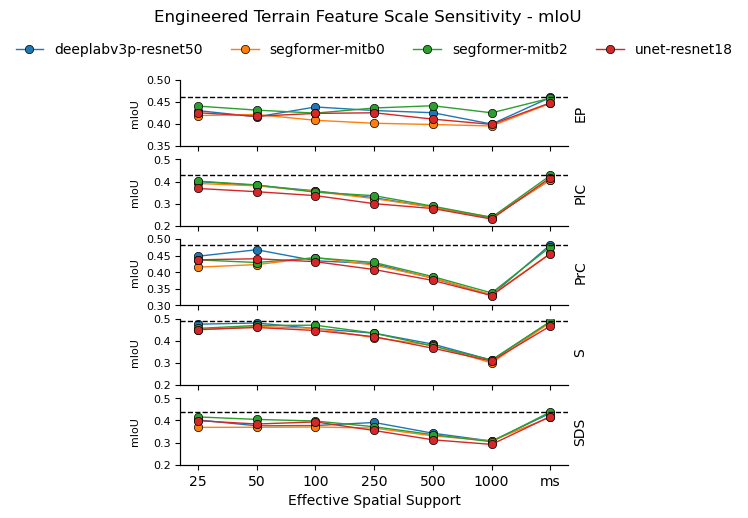

In [9]:
#############################################
# Terrain Feature Scale-Sensitivity - In-domain
#############################################

# path to compiled data...
compiled_path = os.path.join(assets_dir, 'compiled_global.csv')

# metric to plot...
metric = 'iou'
metric_label = 'mIoU'

# output path for figure
output_path = os.path.join(assets_dir, 'scale_sensitivity_iou_id.png')


##### pre-processing...
# read compiled data into df
df_compiled = pd.read_csv(compiled_path)

# parse input modality string into modality family & scale (e.g., ep-51 -> ep, 51)
df_compiled[['family', 'scale']] = df_compiled['input'].apply(lambda x: pd.Series(parse_features(x)))

# define raw sensor feature family & scale (native GSD)...
engineered_features = ['ep', 'plc', 'prc', 's', 'sds']
mask1 = df_compiled['family'] == 'multimodal'
mask2 = df_compiled['family'].isin(engineered_features)
df_compiled.loc[~mask1 & ~mask2, ['family', 'scale']] = 'raw', '5'

# define spatial support (effective recteptive area)...
support_bins = [25, 50, 100, 250, 500, 1000]
support_order = support_bins + ['ms']
df_compiled['spatial_support'] = df_compiled['scale'].apply(lambda x: spatial_support(x, support_bins))
df_compiled['spatial_support'] = pd.Categorical(df_compiled['spatial_support'], categories=support_order, ordered=True)

df_compiled['model-encoder'] = df_compiled['model'] + '-' + df_compiled['encoder']


##### plot...
fig, ax = plt.subplots(nrows=5, figsize=(5,5))
ax = ax.ravel()

# iterate through engineered terrain features...
for idx, fam in enumerate(engineered_features):

    # get terrain feature subset df
    subset = df_compiled[df_compiled['family'] == fam].copy()
    
    # iterate through model architectures & plot line with markers...
    for m in subset['model-encoder'].unique():
        df = subset[subset['model-encoder'] == m].copy()
        df.sort_values('spatial_support', ascending=True, na_position='last', inplace=True)
        df.reset_index(drop=True, inplace=True)
        df['spatial_support'] = df['spatial_support'].astype(str)
        ax[idx].plot(df['spatial_support'], df[f"macro_{metric} (id)"], marker='o', linewidth=1, markeredgecolor='k', markeredgewidth=0.5, label=m)

    max_val = subset[f"macro_{metric} (id)"].max()
    ax[idx].axhline(y=max_val, color='k', linewidth=1, linestyle='--')

    # customize plot...
    ylab = fam.upper() if not fam.startswith('p') else fam[:1].upper() + fam[1:2].lower() + fam[2:].upper()
    ax2 = ax[idx].twinx()
    ax2.set_yticks([])
    ax2.set_ylabel(ylab)
    ax[idx].set_ylabel(f"{metric_label}", fontsize=8)
    ax[idx].set_yticks(ax[idx].get_yticks())
    ax[idx].set_yticklabels(ax[idx].get_yticklabels(), fontsize=8)
    ax[idx].spines['right'].set_visible(False)
    ax[idx].spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['top'].set_visible(False)

# more plot customization...
ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.75), frameon=False, ncols=4)
ax[4].set_xlabel('Effective Spatial Support')
for axes in ax[:-1]:
    axes.set_xticklabels('')
    axes.set_xlabel('')
fig.align_ylabels()
plt.suptitle(f"Engineered Terrain Feature Scale Sensitivity - {metric_label}", y=1.02)

# plot and save...
# plt.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

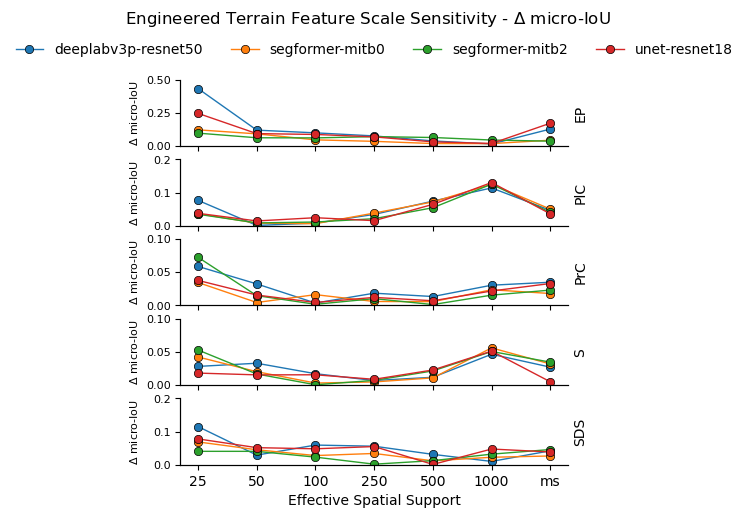

In [45]:
#############################################
# Terrain Feature Scale-Sensitivity - Delta
#############################################

# path to compiled data...
compiled_path = os.path.join(assets_dir, 'compiled_global.csv')

# metric to plot...
metric = 'iou'
metric_label = r'$\Delta$ micro-IoU'

# output path for figure
output_path = os.path.join(assets_dir, 'scale_sensitivity_delta_id.png')


##### pre-processing...
# read compiled data into df
df_compiled = pd.read_csv(compiled_path)

# parse input modality string into modality family & scale (e.g., ep-51 -> ep, 51)
df_compiled[['family', 'scale']] = df_compiled['input'].apply(lambda x: pd.Series(parse_features(x)))

# define raw sensor feature family & scale (native GSD)...
engineered_features = ['ep', 'plc', 'prc', 's', 'sds']
mask1 = df_compiled['family'] == 'multimodal'
mask2 = df_compiled['family'].isin(engineered_features)
df_compiled.loc[~mask1 & ~mask2, ['family', 'scale']] = 'raw', '5'

# define spatial support (effective recteptive area)...
support_bins = [25, 50, 100, 250, 500, 1000]
support_order = support_bins + ['ms']
df_compiled['spatial_support'] = df_compiled['scale'].apply(lambda x: spatial_support(x, support_bins))
df_compiled['spatial_support'] = pd.Categorical(df_compiled['spatial_support'], categories=support_order, ordered=True)

df_compiled['model-encoder'] = df_compiled['model'] + '-' + df_compiled['encoder']

df_compiled['delta'] = np.abs(df_compiled[f"micro_{metric} (id)"] - df_compiled[f"micro_{metric} (cd)"])

##### plot...
fig, ax = plt.subplots(nrows=5, figsize=(5,5))
ax = ax.ravel()

# iterate through engineered terrain features...
for idx, fam in enumerate(engineered_features):

    # get terrain feature subset df
    subset = df_compiled[df_compiled['family'] == fam].copy()
    
    # iterate through model architectures & plot line with markers...
    for m in subset['model-encoder'].unique():
        df = subset[subset['model-encoder'] == m].copy()
        df.sort_values('spatial_support', ascending=True, na_position='last', inplace=True)
        df.reset_index(drop=True, inplace=True)
        df['spatial_support'] = df['spatial_support'].astype(str)
        ax[idx].plot(df['spatial_support'], df[f"delta"], marker='o', linewidth=1, markeredgecolor='k', markeredgewidth=0.5, label=m)

    # min_val = subset['delta'].min()
    # ax[idx].axhline(y=min_val, color='k', linewidth=1, linestyle='--')

    # customize plot...
    ylab = fam.upper() if not fam.startswith('p') else fam[:1].upper() + fam[1:2].lower() + fam[2:].upper()
    ax2 = ax[idx].twinx()
    ax2.set_yticks([])
    ax2.set_ylabel(ylab)
    ax[idx].set_ylim(0)
    ax[idx].set_ylabel(f"{metric_label}", fontsize=8)
    ax[idx].set_yticks(ax[idx].get_yticks())
    ax[idx].set_yticklabels(ax[idx].get_yticklabels(), fontsize=8)
    ax[idx].spines['right'].set_visible(False)
    ax[idx].spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['top'].set_visible(False)

# more plot customization...
ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.75), frameon=False, ncols=4)
ax[4].set_xlabel('Effective Spatial Support')
for axes in ax[:-1]:
    axes.set_xticklabels('')
    axes.set_xlabel('')
fig.align_ylabels()
plt.suptitle(f"Engineered Terrain Feature Scale Sensitivity - {metric_label}", y=1.02)

# plot and save...
plt.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

### Cross-domain Robustness

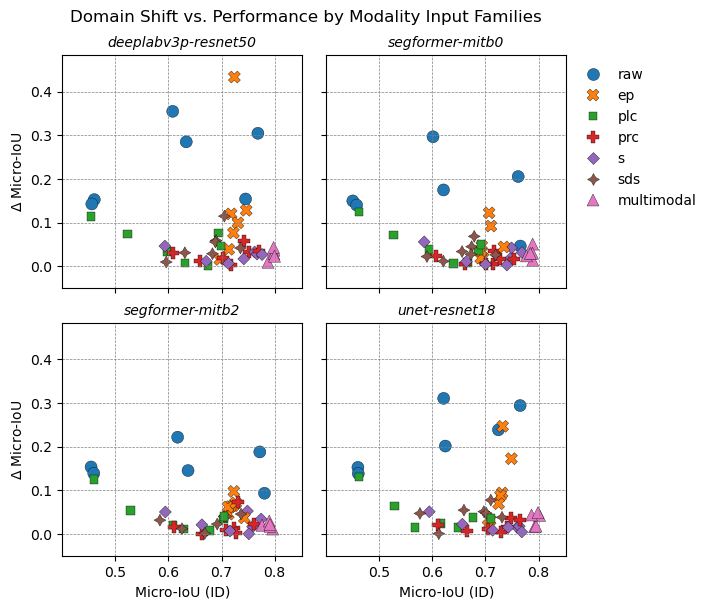

In [51]:
#############################################
# Cross-domain Performance - Delta Scatter plot
#############################################

# path to compiled data...
compiled_path = os.path.join(assets_dir, 'compiled_global.csv')

# metric to plot...
metric = 'iou'
metric_label = 'Micro-IoU'

# define variables...
engineered_features = ['ep', 'plc', 'prc', 's', 'sds']
support_bins = [25, 50, 100, 250, 500, 1000]
support_order = support_bins + ['ms']
size_map = {k:v for k, v in zip(support_order, np.arange(10, 175, 25))}
family_order = ['raw', 'ep', 'plc', 'prc', 's', 'sds', 'multimodal']

# output path for figure
output_path = os.path.join(assets_dir, 'cross_performance_scatter_delta.png')


##### pre-processing...
# read compiled data into df
df_compiled = pd.read_csv(compiled_path)

# parse input modality string into modality family & scale (e.g., ep-51 -> ep, 51)
df_compiled[['family', 'scale']] = df_compiled['input'].apply(lambda x: pd.Series(parse_features(x)))

# define raw sensor feature family & scale (native GSD)...
mask1 = df_compiled['family'] == 'multimodal'
mask2 = df_compiled['family'].isin(engineered_features)
df_compiled.loc[~mask1 & ~mask2, ['family', 'scale']] = 'raw', '5'

# define spatial support (effective recteptive area)...
df_compiled['spatial_support'] = df_compiled['scale'].apply(lambda x: spatial_support(x, support_bins))
df_compiled['spatial_support'] = pd.Categorical(df_compiled['spatial_support'], categories=support_order, ordered=True)

# calculate cross-domain performance gap
df_compiled['delta'] = np.abs(df_compiled[f"micro_{metric} (id)"] - df_compiled[f"micro_{metric} (cd)"])

df_compiled['model-encoder'] = df_compiled['model'] + '-' + df_compiled['encoder']


#### plot delta scatter plot...
fig, ax = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True, figsize=(6.5,6.5))
fig.subplots_adjust(wspace=0.1, hspace=0.15)
ax = ax.ravel()

xmin = df_compiled[f"micro_{metric} (id)"].min() - 0.05
xmax = df_compiled[f"micro_{metric} (id)"].max() + 0.05
ymin = df_compiled['delta'].min() - 0.05
ymax = df_compiled['delta'].max() + 0.05

# iterate over model architectures...
models = df_compiled['model-encoder'].unique()
for idx, m in enumerate(models):

    # get subsets for specific architecture and multiscale...
    subset = df_compiled[df_compiled['model-encoder'] == m].copy()

    # plot scatterplot of each model architecture...
    legend = False
    if idx == 1:
        legend = True
    sns.scatterplot(ax=ax[idx], data=subset, x=f"micro_{metric} (id)", y='delta', hue='family', style='family', s=75, linewidth=0.25, edgecolor='k', legend=legend)

    # customize plot...
    ax[idx].set_xlim(xmin, xmax)
    ax[idx].set_ylim(ymin, ymax)
    ax[idx].set_xlabel(f"{metric_label} (ID)")
    ylab = r'$\Delta$ ' + f"{metric_label}"
    ax[idx].set_ylabel(ylab)
    # if 'resnet' in m:
    #     name = 'ResNet' + m[-2:]
    #     ax[idx].set_title(name, style='italic', fontsize=10)
    # elif 'vit' in m:
    #     ax[idx].set_title('ViT', style='italic', fontsize=10)
    # elif 'swin' in m:
    #     ax[idx].set_title('Swin', style='italic', fontsize=10)
    ax[idx].set_title(subset['model-encoder'].unique().item(), style='italic', fontsize=10)
    ax[idx].grid(axis='both', linestyle='--', linewidth=0.5, color='0.5')
    
# legend
ax[1].legend(loc='upper left', bbox_to_anchor=(1,1), frameon=False)
plt.suptitle('Domain Shift vs. Performance by Modality Input Families', y=0.95)

# save and show...
# plt.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

### Performance vs. MMD

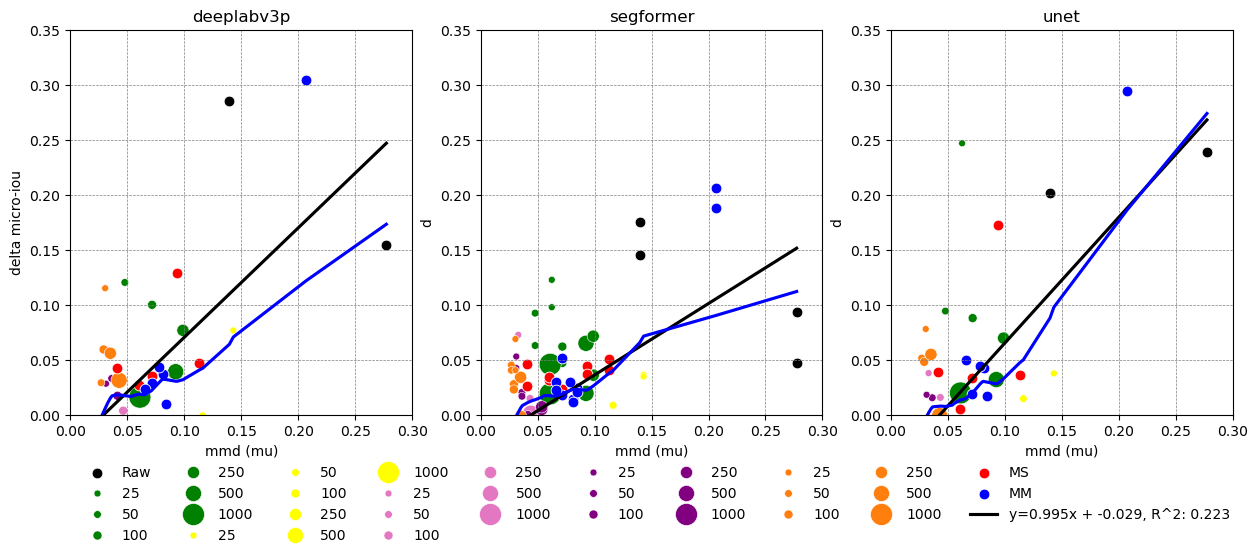

In [7]:

#############################################
# Performance vs. MMD
#############################################

# paths to compiled data...
compiled_path = os.path.join(assets_dir, 'compiled_global.csv')
mmd_path = glob.glob(r'../assets/data_eda/*mmd_summary.csv')[0]

# metric to plot...
metric = 'd'


# ##### pre-processing...
df_compiled = pd.read_csv(compiled_path)
df_compiled[["family", "spatial support"]] = df_compiled["input"].apply(parse_input_label)
df_mmd = pd.read_csv(mmd_path)
# df_mmd['input'] = df_mmd['input'].apply(lambda x: str(x).lower().replace(' ', '-'))
df = pd.merge(left=df_compiled, right=df_mmd, left_on='input', right_on='input', how='inner')


##### calculate regression & plot...
fig, ax = plt.subplots(ncols=3, figsize=(15,5))

for idx, m in enumerate(df['model'].unique()):
    mask = df['model'] == m
    subset = df[mask].copy()

    subset['d'] = subset['micro_iou (id)'] - subset['micro_iou (cd)']
    subset['dr'] = (subset['micro_iou (id)'] - subset['micro_iou (cd)']) / subset['micro_iou (id)'] * 100

    res = stats.linregress(subset["mmd (mu)"], subset[f"{metric}"])
    r2 = res.rvalue**2
    label = f"y={round(res.slope, 3)}x + {round(res.intercept, 3)}, R^2: {round(r2.item(), 3)}"

    sns.scatterplot(data=subset[subset['family'] == 'raw'], x='mmd (mu)', y=f"{metric}", ax=ax[idx], color='k', s=60, label='Raw')

    sns.scatterplot(data=subset[subset['family'] == 'ep'], x='mmd (mu)', y=f"{metric}", ax=ax[idx], color='green', size='spatial support', sizes=(25, 250))
    sns.scatterplot(data=subset[subset['family'] == 'plc'], x='mmd (mu)', y=f"{metric}", ax=ax[idx], color='yellow', size='spatial support', sizes=(25, 250))
    sns.scatterplot(data=subset[subset['family'] == 'prc'], x='mmd (mu)', y=f"{metric}", ax=ax[idx], color='tab:pink', size='spatial support', sizes=(25, 250))
    sns.scatterplot(data=subset[subset['family'] == 's'], x='mmd (mu)', y=f"{metric}", ax=ax[idx], color='purple', size='spatial support', sizes=(25, 250))
    sns.scatterplot(data=subset[subset['family'] == 'sds'], x='mmd (mu)', y=f"{metric}", ax=ax[idx], color='tab:orange', size='spatial support', sizes=(25, 250))

    sns.scatterplot(data=subset[subset['family'] == 'multi-scale'], x='mmd (mu)', y=f"{metric}", ax=ax[idx], color='red', s=60, label='MS')
    sns.scatterplot(data=subset[subset['family'] == 'multimodal'], x='mmd (mu)', y=f"{metric}", ax=ax[idx], color='blue', s=60, label='MM')

    x = sns.regplot(data=subset, x='mmd (mu)', y=f"{metric}", robust=False, ci=False, label=label, color='k', scatter=False, ax=ax[idx])
    sns.regplot(data=subset, x='mmd (mu)', y=f"{metric}", lowess=True, robust=False, ci=False, color='blue', scatter=False, ax=ax[idx])


    ax[idx].set_title(f"{m}")
    ax[idx].set_ylim(0, 0.35)
    ax[idx].set_xlim(0, 0.3)

    ax[idx].grid(axis='both', linestyle='--', linewidth=0.5, color='0.5')

for axes in ax:
    axes.legend().remove()
ax[0].legend(loc='upper left', bbox_to_anchor=(0,-0.1), frameon=False, ncols = 10)
ax[0].set_ylabel("delta micro-iou")

plt.savefig(f"{ASSETS_DIR}/baselines/segmentation/delta_vs_mmd_seg.svg", format='svg', bbox_inches='tight')
plt.show()

# **Class-wise Performance**

## *Experiment Compilation*

In [ ]:
##################################################
# Compile Per-Class Performance Metrics - Single
##################################################

# # output path for compilation
# output_path = os.path.join(assets_dir, 'single_class.csv')


##### compile in- & cross-domain data...
# initialize df
df_single = pd.DataFrame(columns=['model', 'encoder', 'input'])

# collect data from all experiments...
idx = 0
for d in single_dirs:
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0].split('-')[0]
    encoder_name = meta[0].split('-')[1]
    modalities = meta[1]

    # in-domain...
    id_global_path = os.path.join(d, 'id_overall_class.csv')
    id = pd.read_csv(id_global_path)
    id.set_index('class', inplace=True, drop=True)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_overall_class.csv')
    cd = pd.read_csv(cd_global_path)
    cd.set_index('class', inplace=True, drop=True)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge in- & cross-domain subsets...
    df = pd.merge(left=id, right=cd, how='left', left_index=True, right_index=True)
    df.reset_index(inplace=True)

    # combine datasets...
    df_single = pd.concat([df_single, df], ignore_index=True, axis=0)
    df_single.loc[idx:idx+(len(df)), 'model'] = model_name
    df_single.loc[idx:idx+(len(df)), 'encoder'] = encoder_name
    df_single.loc[idx:idx+(len(df)), 'input'] = modalities

    idx += len(df)

# # save & display...
# df_single.to_csv(output_path, index=False)
# df_single.head()

In [ ]:
##################################################
# Compile Per-Class Performance Metrics - Multi-scale
##################################################

# # output path for compilation
# output_path = os.path.join(assets_dir, 'multiscale_class.csv')


##### compile in- & cross-domain data...
# initialize df
df_ms = pd.DataFrame(columns=['model', 'encoder', 'input'])

# collect data from all experiments...
idx = 0
for d in ms_dirs:
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0].split('-')[0]
    encoder_name = meta[0].split('-')[1]
    modalities = meta[1]

    # in-domain...
    id_global_path = os.path.join(d, 'id_overall_class.csv')
    id = pd.read_csv(id_global_path)
    id.set_index('class', inplace=True, drop=True)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_overall_class.csv')
    cd = pd.read_csv(cd_global_path)
    cd.set_index('class', inplace=True, drop=True)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge in- & cross-domain subsets...
    df = pd.merge(left=id, right=cd, how='left', left_index=True, right_index=True)
    df.reset_index(inplace=True)

    # combine datasets...
    df_ms = pd.concat([df_ms, df], ignore_index=True, axis=0)
    df_ms.loc[idx:idx+(len(df)), 'model'] = model_name
    df_ms.loc[idx:idx+(len(df)), 'encoder'] = encoder_name
    df_ms.loc[idx:idx+(len(df)), 'input'] = modalities

    idx += len(df)

# # save & display...
# df_ms.to_csv(output_path, index=False)
# df_ms.head()

In [ ]:
##################################################
# Compile Per-Class Performance Metrics - Multimodal
##################################################

# # output path for compilation
# output_path = os.path.join(assets_dir, 'multimodal_class.csv')


##### compile in- & cross-domain data...
# initialize df
df_mm = pd.DataFrame(columns=['model', 'encoder', 'input'])

# collect data from all experiments...
idx = 0
for d in mm_dirs:
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0].split('-')[0]
    encoder_name = meta[0].split('-')[1]
    modalities = meta[1]

    # in-domain...
    id_global_path = os.path.join(d, 'id_overall_class.csv')
    id = pd.read_csv(id_global_path)
    id.set_index('class', inplace=True, drop=True)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_overall_class.csv')
    cd = pd.read_csv(cd_global_path)
    cd.set_index('class', inplace=True, drop=True)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge in- & cross-domain subsets...
    df = pd.merge(left=id, right=cd, how='left', left_index=True, right_index=True)
    df.reset_index(inplace=True)

    # combine datasets...
    df_mm = pd.concat([df_mm, df], ignore_index=True, axis=0)
    df_mm.loc[idx:idx+(len(df)), 'model'] = model_name
    df_mm.loc[idx:idx+(len(df)), 'encoder'] = encoder_name
    df_mm.loc[idx:idx+(len(df)), 'input'] = modalities

    idx += len(df)

# # save & display...
# df_mm.to_csv(output_path, index=False)
# df_mm.head()

In [ ]:
##################################################
# Compile All Global Experiments
##################################################

# # paths to single, multi-scale, & multimodal compilations...
# single_path = os.path.join(assets_dir, "single_class.csv")
# ms_path = os.path.join(assets_dir, "multiscale_class.csv")
# mm_path = os.path.join(assets_dir, "multimodal_class.csv")

# output path
output_path = os.path.join(assets_dir, 'compiled_class.csv')


##### compile data...
# df_list = []
# df_list.append(pd.read_csv(single_path))
# df_list.append(pd.read_csv(ms_path))
# df_list.append(pd.read_csv(mm_path))

df = pd.concat([df_single, df_ms, df_mm])
df.reset_index(drop=True, inplace=True)

df.to_csv(output_path, index=False)
df.head()

,model,encoder,input,class,gt_support (id),pred_support (id),gt_num_images (id),pred_num_images (id),tp (id),fp (id),...,macro_iou (cd),macro_dice (cd),macro_precision (cd),macro_recall (cd),mean_hd (cd),mean_hd95 (cd),micro_iou (cd),micro_dice (cd),micro_precision (cd),micro_recall (cd)
0,deeplabv3p,resnet50,dem,Qaf,10183.0,0.0,10.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
1,deeplabv3p,resnet50,dem,Qal,8361713.0,7536136.0,947.0,928.0,5980234.0,1555902.0,...,0.137092,0.188426,0.314983,0.180292,141.442329,126.829787,0.228576,0.372099,0.608144,0.268055
2,deeplabv3p,resnet50,dem,Qat,388848.0,268789.0,61.0,60.0,94148.0,174641.0,...,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
3,deeplabv3p,resnet50,dem,Qc,16237424.0,17202215.0,748.0,807.0,14663487.0,2538728.0,...,0.213697,0.275945,0.229029,0.435821,130.693717,111.436685,0.434113,0.605410,0.445544,0.944196
4,deeplabv3p,resnet50,dem,Qca,7202703.0,5861922.0,431.0,419.0,3971679.0,1890243.0,...,0.028692,0.045314,0.126181,0.039797,172.521181,158.150522,0.069393,0.129781,0.146740,0.116336


## *Visualizations*

### Performance vs. Class-area Proportion

In [ ]:

# modality configuration
exp = 'ep-ms+prc-ms+s-ms'
# exp = 'ep-51'

# relevant experiment directories (modality config fun in all models)
exp_dirs = glob.glob(f"../experiments/baselines/segmentation/**/*{exp}*")

# model predictions of in-domain test set
pred_paths = [os.path.join(d, 'id_img_class.csv') for d in exp_dirs]
pred_paths = [d for d in pred_paths if 'variance' not in d]

# class area proportions path
areas_path = glob.glob(r'../data/*areas.csv')[0]

# ouput path
output_path = os.path.join(assets_dir, 'prob_vs_area.png')


##### plot...
# read areas dataframe 
areas = pd.read_csv(areas_path)

# spatial_corr = {}
# imbalance_corr = {}

# set up figure...one subplot for each model
fig, ax = plt.subplots(ncols=4, sharey=True, figsize=(16,4))

# iterate through each model experiment...
for idx, path in enumerate(pred_paths):

    model = os.path.dirname(path)
    model = os.path.basename(model).split('_')[0]


    preds = pd.read_csv(path)                                                           # read predictions into dataframe
    df = preds.merge(right=areas, how='left', on='patch_id', suffixes=['', '_area'])    # merge with area proportions
    df.set_index('patch_id', drop=True, inplace=True)                                   # reset index using patch_id

    # define class probability & class area proportions columns...
    area_cols = [col for col in df.columns if 'area' in col]
    prob_cols = [col.split('_')[0] for col in area_cols]

    # iterate through each class...
    for a, p in zip(area_cols, prob_cols):

        df2 = df[[a, p]].copy()                                              # subset dataframe for class of interest
        df2 = df2[df2[a] > 0]                                                # only process patches with class presence


        # plot lowess curve...
        sns.regplot(ax=ax[idx], data=df2, x=a, y=p, lowess=True, scatter=False, label=p)
        sns.scatterplot(ax=ax[idx], data=df2, x=a, y=p, edgecolor='0.5', s=10, facecolor='none')

    # customize plot...
    ax[idx].legend(loc='lower right', bbox_to_anchor=(1, 0), frameon=False, fontsize=8, title='LOWESS')
    ax[idx].set_title(model)
    ticks = np.arange(0, 1.01, 0.2)
    ax[idx].set_xlabel('Class Area Proportion')
    ax[idx].set_xticks(ticks)
    ax[idx].set_xticklabels(ax[idx].get_xticklabels(), fontsize=8)
    ax[idx].set_yticks(ticks)
    ax[idx].set_yticklabels([])
    ax[idx].set_ylabel('')
    ax[idx].grid(axis='both', linewidth=0.5, linestyle='--')
    ax[idx].spines['right'].set_visible(False)
    ax[idx].spines['top'].set_visible(False)

# set y axis for first plot...
ax[0].set_ylabel('IoU')
ax[0].set_yticks(ticks)
ax[0].set_yticklabels([str(round(s, 1)) for s in ticks], fontsize=8)

# save and show...
# plt.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=300)
# plt.savefig(r'../assets/baselines/classification/prob_vs_area.svg')
plt.show()

### Class Performance Heatmap

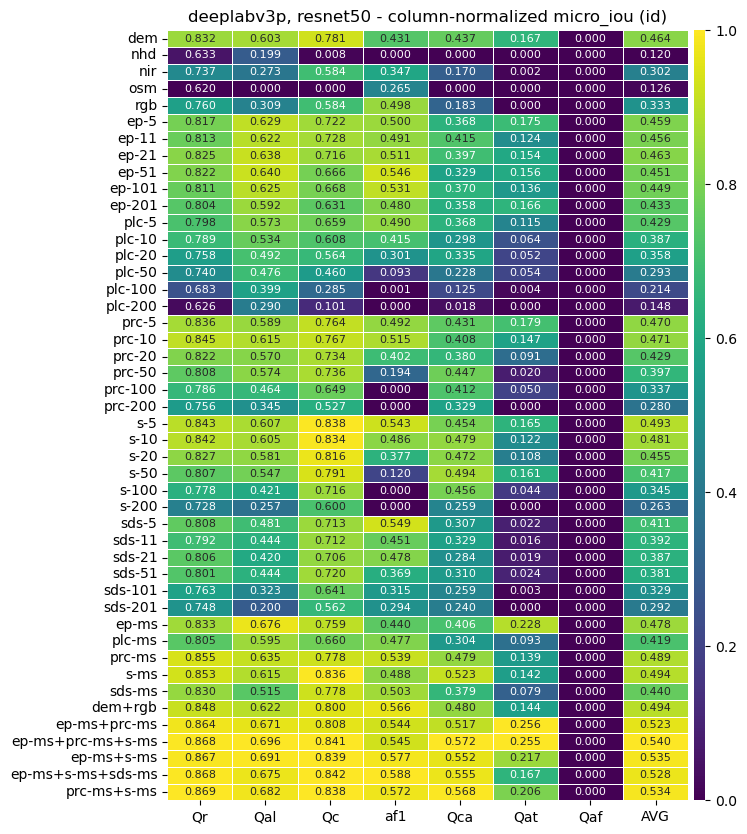

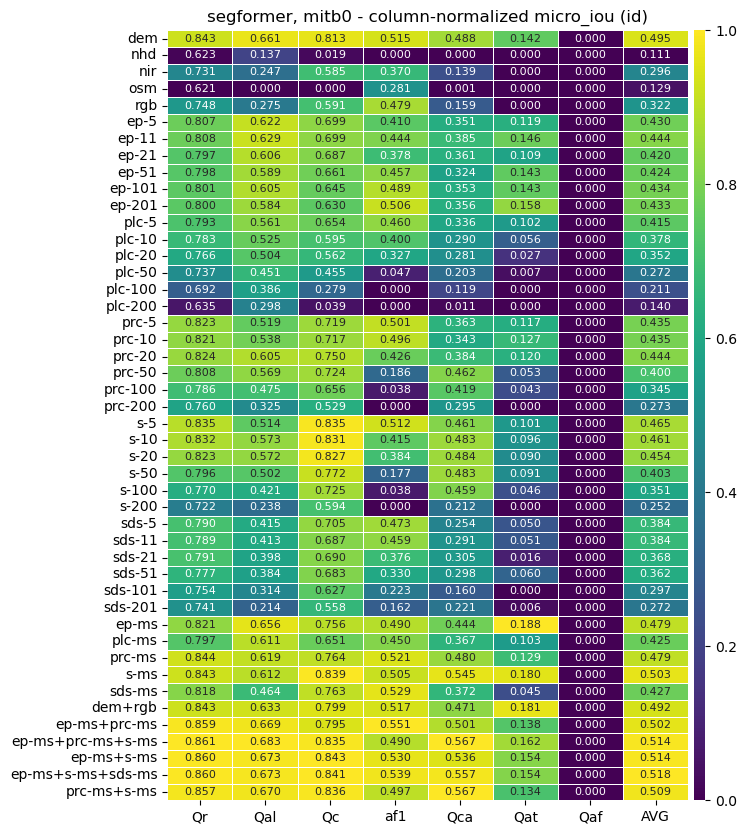

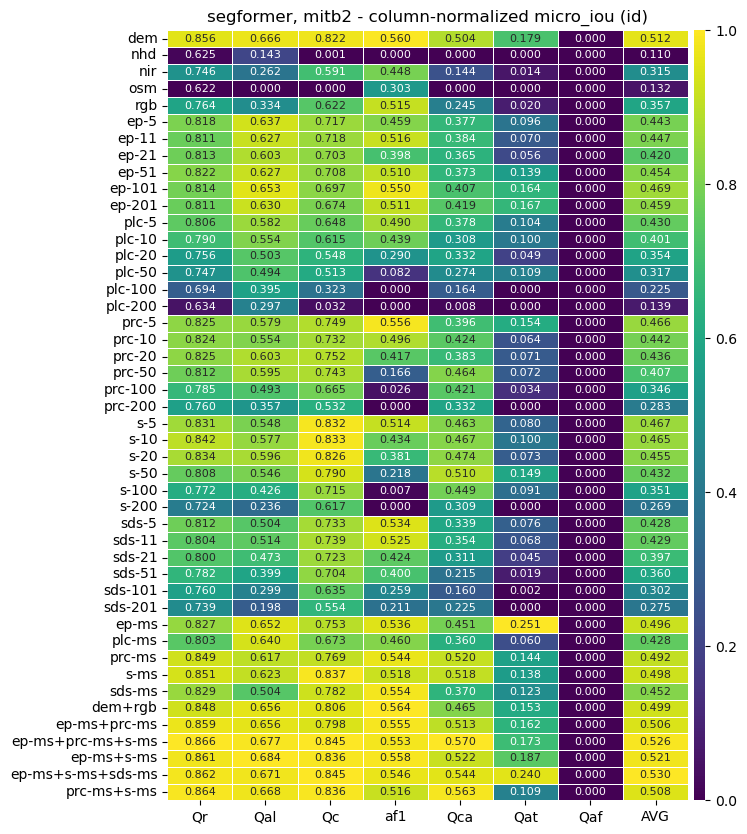

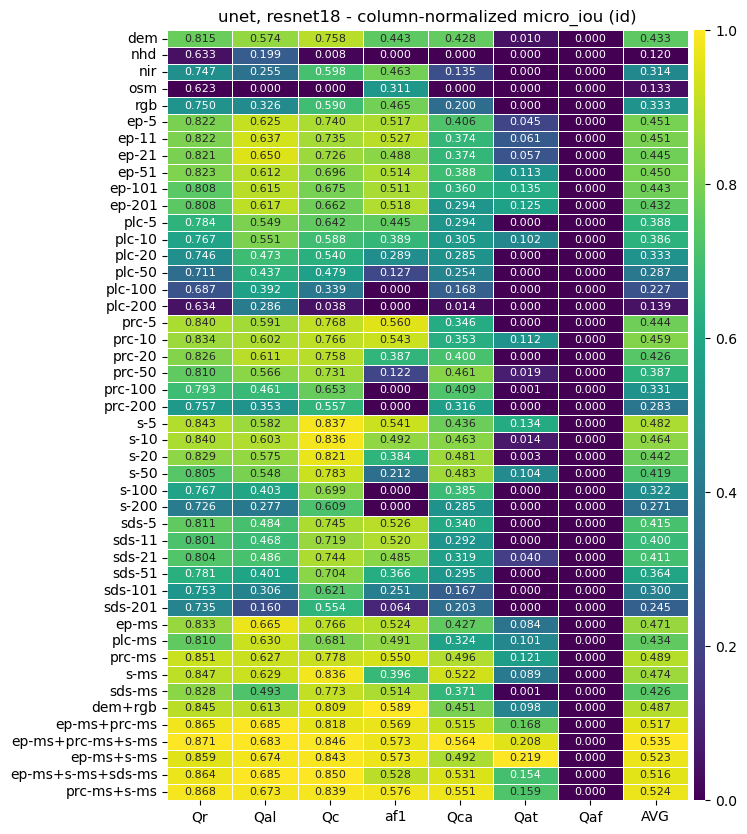

In [36]:


class_path = os.path.join(f"{ASSETS_DIR}/baselines/segmentation/compiled_class.csv")

metric = "micro_iou (id)"


df = pd.read_csv(class_path)

for model_encoder in np.unique(df['model'] + '-' + df['encoder']):

    m, e = model_encoder.split('-')

    subset = df[df["model"] == m].copy()
    subset = subset[subset['encoder'] == e]
    subset[["family", "spatial support"]] = subset["input"].apply(parse_input_label)

    class_order = ["Qr", "Qal", "Qc", "af1", "Qca", "Qat", "Qaf"]
    heatmap_order = class_order + ["AVG"]
    family_rank = {"raw": 0, "ep": 1, "plc": 2, "prc": 3, "s": 4, "sds": 5, "multi-scale": 6, "multimodal": 7}
    support_families = ["ep", "plc", "prc", "s", "sds"]

    subset["family_rank"] = subset["family"].map(family_rank)
    subset["support_sort"] = np.where(subset["family"].isin(support_families), pd.to_numeric(subset["spatial support"], errors="coerce"), np.nan)
    subset["alpha_sort"] = subset["input"].astype(str).str.lower()
    subset = subset.sort_values(by=["family_rank", "support_sort", "alpha_sort"], na_position="last")

    row_order = subset["input"].drop_duplicates()
    heatmap_df = subset.pivot(index="input", columns="class", values=metric).loc[row_order, class_order]
    heatmap_df['AVG'] = heatmap_df[class_order].mean(axis=1)

    # heatmap_df = heatmap_df.loc[:'sds-201']
    heatmap_norm = (heatmap_df - heatmap_df.min(axis=0)) / (heatmap_df.max(axis=0) - heatmap_df.min(axis=0))
    heatmap_norm.fillna(0, inplace=True)


    fig, ax = plt.subplots(figsize=(8,10))

    sns.heatmap(
        heatmap_norm[heatmap_order],
        annot=heatmap_df[heatmap_order],
        fmt=".3f",
        cmap="viridis",
        linewidths=0.5,
        annot_kws={'fontsize': 8},
        cbar_kws={'pad':0.01, 'aspect':70},
        ax=ax
        )

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(f"{m}, {e} - column-normalized {metric}")

    # plt.tight_layout()
    plt.savefig(f"{assets_dir}class_heatmap_{m}_{e}.svg", format='svg', bbox_inches='tight')
    plt.show()

    # break

### Masks by Performance Category Examples

In [ ]:
#############################################
# Example Segmentation Masks by Performance
#############################################

# modality configuration
exp = 'ep-ms+prc-ms+s-ms'

# relevant experiment directories (modality config fun in all models)
exp_dirs = glob.glob(f"../experiments/baselines/segmentation/**/*{exp}*")

# model predictions of in-domain test set
pred_paths = [os.path.join(d, 'id_img_class.csv') for d in exp_dirs]

# class area proportions...
areas_path = glob.glob(r'../data/*areas.csv')[0]

# ouput path
output_path = os.path.join(assets_dir, 'example_masks.png')

seed = 111



##### pre-processing & plotting...
# setup plot
fig, ax = plt.subplots(nrows=4, ncols=8, figsize=(16, 8))
ax = ax.ravel()

# define color map using standard colors
cmap = ListedColormap(list(SG_COLORS.values()))

# initialize subplot row number...
row = 0

# iterate through img/class metrics files for each model-encoder... 
for path in pred_paths:


    ###### pre-processing....
    # read img/class CSV to df
    df = pd.read_csv(path)
    
    # filter samples...
    mask1 = (df['gt_support'] > 0) | (df['pred_support'] > 0)              # rows with true or predicted classes in patch...
    mask2 = df.groupby('patch_id')['gt_present'].transform('sum') > 1      # at least two classes present
    df = df[mask1 & mask2]

    # aggregate class metrics to patch-level performance (single metric per sample)...
    patch_summary = df.groupby('patch_id').apply(lambda x: pd.Series({'weighted_iou': np.average(x['iou'], weights=x['gt_support'])}))
    patch_summary['weighted_iou'] = patch_summary['weighted_iou'].clip(0., 1.)

    # create performance/area bins...
    patch_summary['bin'] = pd.cut(patch_summary['weighted_iou'], bins=[0., .25, .5, .75, 1.], labels=['Q1', 'Q2', 'Q3', 'Q4'], include_lowest=True)

    # randomly sample one patch per bin...
    samples = patch_summary.groupby('bin').apply(lambda x: x.sample(1, random_state=seed)).reset_index()


    ##### evaluate selected samples with model & pre-trained weights...
    # get relevant paths...
    exp_dir = os.path.abspath(os.path.dirname(path))     # experiment directory
    config_path = os.path.join(exp_dir, 'config.yml')    # path to config.yml file for experiment
    with open(config_path, 'r') as file:                 # open config.yml as dict
        cfg = yaml.safe_load(file)
    ckpt_path = cfg['experiment']['best_model']          # path to best model / checkpoint .pth file

    # define model parameters...
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model_name = cfg['model']['model_name']
    encoder_name = cfg['model']['encoder_name']
    in_channels = cfg['model']['in_channels']
    output_size = cfg['model']['output_size']

    # initialize correct model & load weights...
    if model_name == 'unet':
        model = create_unet_seg(in_channels=in_channels, num_classes=output_size, encoder_name=encoder_name).to(device)
    elif model_name == 'deeplabv3p':
        model = create_deeplabv3p_seg(in_channels=in_channels, num_classes=output_size, encoder_name=encoder_name).to(device)
    elif model_name == 'segformer':
        model = create_segformer_seg(in_channels=in_channels, num_classes=output_size, encoder_name=encoder_name).to(device)
    state_dict = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state_dict)

    # collect required input information for dataloader...
    inp = cfg['data']['input'][exp]
    channels = inp['channels']                                                     # number of input channels
    means = inp['mean']                                                            # list of means for input channels
    sds = inp['sd']                                                                # list of standard dev. for input channels
    patch_dirs = [f"../{cfg['data']['root']}/{d}" for d in cfg['data']['dirs']]    # directory paths containing data channels/modalities


    ##### plot masks...
    # initialize subplot column number
    col = 0

    # iterate through four sample selections (based on performance/difficulty)...
    for _, sample in samples.iterrows():

        # create input dataloader...
        input_dict = {exp: {'channels': channels, 'mean': means, 'sd': sds}}
        ds = ESDataset_Classification([sample['patch_id']], patch_dirs, input_dict, areas_path, task='segmentation')
        dl = DataLoader(ds)

        # evaluate sample with model & get prediction & target masks...
        prediction, mask = test_model_seg(model, dl, device)
        prediction = prediction.squeeze(0)
        mask = mask.squeeze(0)

        # plot target & prediction masks side-by-side (fix colors to 0-6)
        ax[col+row].imshow(mask, cmap=cmap, vmin=0, vmax=6)
        ax[col+row+1].imshow(prediction, cmap=cmap, vmin=0, vmax=6)

        # plot model-encoder name along y-axis on left column only...
        if col == 0:
            ax[col+row].text(-0.15, 0.5, f"{model_name}\n({encoder_name})", transform=ax[col+row].transAxes, fontsize=10, rotation=90, ha='center', va='center')
        
        # increase column number by 2
        col += 2

    # increase row number by 8 (for 8 subplots per row)
    row += 8

# turn off axis ticks/labels...
for axes in ax:
    axes.set_xticks([])
    axes.set_yticks([])
    for spine in axes.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(0.5)

# plot GT/Predicted titles...
for j in range(8):
    if j % 2 == 0:
        ax[j].set_title("GT", fontsize=10, style='italic')
    else:
        ax[j].set_title("Predicted", fontsize=10, style='italic')

# plot performance/difficulty category...
pair_centers = [(1/8)*(1.5*k+1)+0.1 for k in range(4)]
bin_labels = ["Wt. IoU: 0-0.25", "Wt. IoU: 0.25-0.5", "Wt. IoU: 0.5-0.75", "Wt. IoU: 0.75-1.0"]
for x, label in zip(pair_centers, bin_labels):
    fig.text(x, 0.93, label, ha='center', va='center', fontsize=12)

plt.suptitle('Randomly Selected Examples by Weighted IoU of In-domain Ground Truth and Predicted Segmentation Masks')
# plt.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

# **Correlations**

## *Dataset Class Imbalance*

In [33]:
#####
# In-domain Performance vs. Class Frequency


# paths to compiled data...
compiled_path = os.path.join(assets_dir, 'compiled_class.csv')
stats_path = glob.glob(r'../assets/data_eda/*imbalance_metrics.csv')[0]

response = 'micro_iou (id)'
predictor = 'N_eff'

##### pre-processing & calculate correlation...
df_compiled = pd.read_csv(compiled_path)
df_stats = pd.read_csv(stats_path)
df = pd.merge(left=df_compiled, right=df_stats, how='inner', on='class')


df_corr = pd.DataFrame({
    "r2": df.groupby(['model', 'encoder', 'input']).apply(lambda g: g[predictor].corr(g[response], method="pearson"))**2,
    "pcc": df.groupby(['model', 'encoder', 'input']).apply(lambda g: g[predictor].corr(g[response], method="pearson")),
    "srcc": df.groupby(['model', 'encoder', 'input']).apply(lambda g: g[predictor].corr(g[response], method="spearman")),
    "krcc": df.groupby(['model', 'encoder', 'input']).apply(lambda g: g[predictor].corr(g[response], method="kendall"))
    })

df_corr_avg = df_corr.groupby(['model', 'encoder']).mean().reset_index()
df_corr_avg.to_csv(f"{assets_dir}/correlation_n_effective.csv", index=False)
df_corr_avg

,model,encoder,r2,pcc,srcc,krcc
0,deeplabv3p,resnet50,0.820402,0.899876,0.917150,0.836984
1,segformer,mitb0,0.810480,0.894091,0.919084,0.834664
2,segformer,mitb2,0.820482,0.899311,0.909996,0.827011
3,unet,resnet18,0.821178,0.899876,0.921219,0.837481


## *Intra-patch Spatial Support*

## *Inter-region Geographic Robustness*

In [35]:
#####
# Performance Degradation vs. MMD
#####

# paths to compiled data...
compiled_path = os.path.join(assets_dir, 'compiled_global.csv')
mmd_path = glob.glob(r'../assets/data_eda/*mmd_summary.csv')[0]

metric = 'macro_iou'
response = 'delta'
predictor = 'mmd (mu)'

##### pre-processing & calculate correlation...
df_compiled = pd.read_csv(compiled_path)
df_mmd = pd.read_csv(mmd_path)
df = pd.merge(left=df_compiled, right=df_mmd, how='inner', on='input')
df['delta'] = df[f"{metric} (id)"] - df[f"{metric} (cd)"]

df_corr = pd.DataFrame({
    "r2": df.groupby(['model', 'encoder']).apply(lambda g: g[predictor].corr(g[response], method="pearson"))**2,
    "pcc": df.groupby(['model', 'encoder']).apply(lambda g: g[predictor].corr(g[response], method="pearson")),
    "srcc": df.groupby(['model', 'encoder']).apply(lambda g: g[predictor].corr(g[response], method="spearman")),
    "krcc": df.groupby(['model', 'encoder']).apply(lambda g: g[predictor].corr(g[response], method="kendall"))
    }).reset_index()

df_corr.to_csv(f"{assets_dir}/correlation_mmd.csv", index=False)
df_corr

,model,encoder,r2,pcc,srcc,krcc
0,deeplabv3p,resnet50,0.283849,0.532775,0.350066,0.238384
1,segformer,mitb0,0.248828,0.498826,0.402767,0.270707
2,segformer,mitb2,0.287142,0.535856,0.370356,0.274747
3,unet,resnet18,0.384005,0.619682,0.369433,0.244444
